#Gaussian Process Classification:

##Laplace Approximation versus Expectation Propagation

This notebook follows chapter 3 of Rasmussen and Williams, Gaussian Processes for Machine Learning, which covers Gaussian process classification (GPC). Since the class posterior for a Gaussian process classifier is not available in closed form, the chapter introduces two approximate inference schemes: the Laplace approximation and expectation propagation, commonly written as EP.We implement both methods from scratch following the equations and algorithms in the book, then compare them on a real classification problem that any computer science graduate student will recognize: separating handwritten digit images. This mirrors the handwritten digit experiment that the book itself uses in section 3.7.3.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.linalg import cho_factor, cho_solve
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import pandas as pd

np.random.seed(0)

###The dataset
We use the digits dataset that ships with scikit learn, eight by eight pixel grayscale images of handwritten digits, the same kind of postal service digit data the original GPML book used for its own classification experiments. We pick two visually similar digits, four and nine, so the task is a genuine, non trivial, real world binary problem.

In [ ]:
digits = load_digits()
mask = (digits.target == 4) | (digits.target == 9)
images = digits.images[mask]
X_raw = digits.data[mask].astype(float)
y_raw = digits.target[mask]

y = np.where(y_raw == 4, 1.0, -1.0)
X = X_raw / 16.0

print("total examples", X.shape[0])
print("feature dimension", X.shape[1])

total examples 361
feature dimension 64


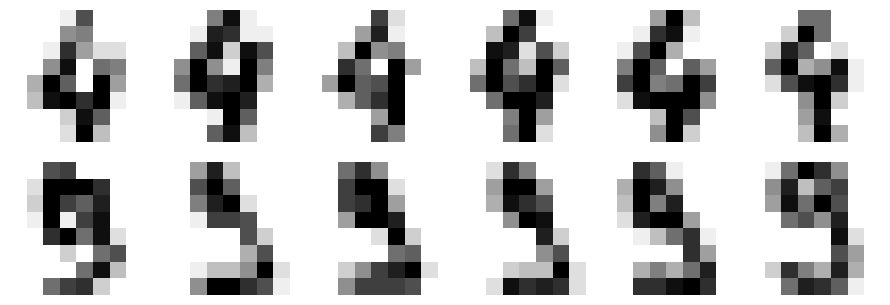

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
idx4 = np.where(y_raw == 4)[0][:6]
idx9 = np.where(y_raw == 9)[0][:6]
for a, i in zip(axes[0], idx4):
    a.imshow(images[i], cmap="gray_r")
    a.axis("off")
for a, i in zip(axes[1], idx9):
    a.imshow(images[i], cmap="gray_r")
    a.axis("off")
axes[0, 0].set_ylabel("digit 4")
axes[1, 0].set_ylabel("digit 9")
plt.tight_layout()
plt.show()

###Model
We place a zero mean Gaussian process prior on a latent function f, and connect f to the binary label through the probit likelihood, p(y = 1 given f) = Phi(f), where Phi is the standard normal cumulative distribution function. The covariance function is the squared exponential kernel: signal variance times exp of minus one half times squared distance divided by length scale squared.

In [ ]:
def kernel_se(X1, X2, length_scale, signal_var):
    sq1 = np.sum(X1 ** 2, axis=1).reshape(-1, 1)
    sq2 = np.sum(X2 ** 2, axis=1).reshape(1, -1)
    sqdist = sq1 + sq2 - 2 * X1 @ X2.T
    sqdist = np.maximum(sqdist, 0)
    return signal_var * np.exp(-0.5 * sqdist / length_scale ** 2)

####Laplace approximation
Finds the mode of the posterior over the latent values by Newton iteration, then approximates the posterior locally around that mode with a Gaussian whose covariance is the inverse Hessian of the negative log posterior. This is Algorithm 3.1 in the book. Returns the mode, the site curvature terms, the Cholesky factor needed for prediction, and the approximate log marginal likelihood from equation 3.32.

In [ ]:
def laplace_train(K, y, tol=1e-8, max_iter=200, jitter=1e-9):
    n = K.shape[0]
    f = np.zeros(n)
    I = np.eye(n)
    obj_old = -np.inf
    a = np.zeros(n)
    for it in range(max_iter):
        z = y * f
        pdf = norm.pdf(f)
        cdf = np.clip(norm.cdf(z), 1e-12, 1.0)
        grad = y * pdf / cdf
        W = (pdf ** 2) / (cdf ** 2) + z * pdf / cdf
        W = np.maximum(W, 1e-10)
        sW = np.sqrt(W)
        B = I + sW[:, None] * K * sW[None, :] + jitter * I
        Lc = cho_factor(B, lower=True)
        b = W * f + grad
        Kb = K @ b
        term = sW * cho_solve(Lc, sW * Kb)
        a = b - term
        f = K @ a
        z = y * f
        cdf_new = np.clip(norm.cdf(z), 1e-12, 1.0)
        obj = -0.5 * a @ f + np.sum(np.log(cdf_new))
        if np.abs(obj - obj_old) < tol:
            obj_old = obj
            break
        obj_old = obj
    z = y * f
    pdf = norm.pdf(f)
    cdf = np.clip(norm.cdf(z), 1e-12, 1.0)
    grad = y * pdf / cdf
    W = (pdf ** 2) / (cdf ** 2) + z * pdf / cdf
    W = np.maximum(W, 1e-10)
    sW = np.sqrt(W)
    B = I + sW[:, None] * K * sW[None, :] + jitter * I
    Lc = cho_factor(B, lower=True)
    log_diag_L = np.sum(np.log(np.diag(Lc[0])))
    log_marg = -0.5 * a @ f + np.sum(np.log(cdf)) - log_diag_L
    return dict(f=f, sW=sW, L=Lc, grad=grad, log_marg=log_marg)


def laplace_predict(Xtrain, Xtest, state, length_scale, signal_var):
    K_s = kernel_se(Xtrain, Xtest, length_scale, signal_var)
    k_ss = signal_var * np.ones(Xtest.shape[0])
    mean = K_s.T @ state["grad"]
    sW = state["sW"]
    L = np.tril(state["L"][0])
    v = np.linalg.solve(L, sW[:, None] * K_s)
    var = k_ss - np.sum(v ** 2, axis=0)
    var = np.maximum(var, 1e-10)
    prob = norm.cdf(mean / np.sqrt(1 + var))
    return prob, mean, var

####Expectation propagation
Algorithm 3.5 in the book. Instead of a single mode, EP approximates each of the n non Gaussian likelihood terms with its own local Gaussian site function, refined one at a time through a cavity distribution and moment matching, over several sweeps until convergence. Returns the natural site parameters and the approximate log marginal likelihood from equation 3.65.

In [ ]:
def ep_train(K, y, tol=1e-6, max_sweeps=40, jitter=1e-9):
    n = K.shape[0]
    tau_tilde = np.zeros(n)
    nu_tilde = np.zeros(n)
    Sigma = K.copy()
    mu = np.zeros(n)
    I = np.eye(n)

    for sweep in range(max_sweeps):
        max_delta = 0.0
        for i in range(n):
            sigma_ii = Sigma[i, i]
            tau_i = 1.0 / sigma_ii
            nu_i = mu[i] / sigma_ii
            tau_cav = tau_i - tau_tilde[i]
            nu_cav = nu_i - nu_tilde[i]
            if tau_cav <= 1e-10:
                continue
            s2 = 1.0 / tau_cav
            m = nu_cav * s2
            denom = np.sqrt(1.0 + s2)
            z = y[i] * m / denom
            pdf_z = norm.pdf(z)
            cdf_z = np.clip(norm.cdf(z), 1e-12, 1.0)
            hat_mu = m + y[i] * s2 * pdf_z / (cdf_z * denom)
            hat_sigma2 = s2 - (s2 ** 2 * pdf_z / (cdf_z * (1.0 + s2))) * (z + pdf_z / cdf_z)
            hat_sigma2 = max(hat_sigma2, 1e-10)

            new_tau_tilde = 1.0 / hat_sigma2 - tau_cav
            new_nu_tilde = hat_mu / hat_sigma2 - nu_cav
            delta_tau = new_tau_tilde - tau_tilde[i]

            max_delta = max(max_delta, abs(delta_tau))

            si = Sigma[:, i].copy()
            denom_update = 1.0 + delta_tau * sigma_ii
            Sigma = Sigma - (delta_tau / denom_update) * np.outer(si, si)

            tau_tilde[i] = new_tau_tilde
            nu_tilde[i] = new_nu_tilde
            mu = Sigma @ nu_tilde

        ssqrt = np.sqrt(np.maximum(tau_tilde, 0))
        B = I + ssqrt[:, None] * K * ssqrt[None, :] + jitter * I
        Lc = cho_factor(B, lower=True)
        L = np.tril(Lc[0])
        V = np.linalg.solve(L, ssqrt[:, None] * K)
        Sigma = K - V.T @ V
        mu = Sigma @ nu_tilde

        if max_delta < tol:
            break

    tau_tilde = np.maximum(tau_tilde, 1e-10)
    sigma_tilde2 = 1.0 / tau_tilde
    mu_tilde = nu_tilde / tau_tilde

    diagSigma = np.diag(Sigma)
    tau_cav = 1.0 / diagSigma - tau_tilde
    nu_cav = mu / diagSigma - nu_tilde
    sigma_cav2 = 1.0 / tau_cav
    mu_cav = nu_cav * sigma_cav2

    M = K + np.diag(sigma_tilde2)
    Lm = cho_factor(M, lower=True)
    term1 = -1.0 * np.sum(np.log(np.diag(Lm[0])))
    term2 = -0.5 * mu_tilde @ cho_solve(Lm, mu_tilde)
    z_i = y * mu_cav / np.sqrt(1 + sigma_cav2)
    term3 = np.sum(np.log(np.clip(norm.cdf(z_i), 1e-12, 1.0)))
    term4 = 0.5 * np.sum(np.log(sigma_cav2 + sigma_tilde2))
    term5 = np.sum((mu_cav - mu_tilde) ** 2 / (2 * (sigma_cav2 + sigma_tilde2)))
    log_marg = term1 + term2 + term3 + term4 + term5

    return dict(tau_tilde=tau_tilde, nu_tilde=nu_tilde, Sigma=Sigma, mu=mu, log_marg=log_marg)


def ep_predict(Xtrain, Xtest, state, length_scale, signal_var):
    K = kernel_se(Xtrain, Xtrain, length_scale, signal_var)
    K_s = kernel_se(Xtrain, Xtest, length_scale, signal_var)
    k_ss = signal_var * np.ones(Xtest.shape[0])
    tau_tilde = state["tau_tilde"]
    nu_tilde = state["nu_tilde"]
    ssqrt = np.sqrt(tau_tilde)
    n = Xtrain.shape[0]
    I = np.eye(n)
    B = I + ssqrt[:, None] * K * ssqrt[None, :] + 1e-9 * I
    Lc = cho_factor(B, lower=True)
    correction = ssqrt * cho_solve(Lc, ssqrt * (K @ nu_tilde))
    mean = K_s.T @ nu_tilde - K_s.T @ correction
    L = np.tril(Lc[0])
    v = np.linalg.solve(L, ssqrt[:, None] * K_s)
    var = k_ss - np.sum(v ** 2, axis=0)
    var = np.maximum(var, 1e-10)
    prob = norm.cdf(mean / np.sqrt(1 + var))
    return prob, mean, var

###Preparing the data for comparison

Split into training and held out test sets, then reduce the sixty four raw pixel features with principal component analysis so the kernel matrix computation stays fast, while keeping enough components to preserve the shape information that separates a four from a nine.

In [ ]:
Xtrain_raw, Xtest_raw, ytrain, ytest = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)

pca = PCA(n_components=8, random_state=0)
Xtrain = pca.fit_transform(Xtrain_raw)
Xtest = pca.transform(Xtest_raw)

print("training examples", Xtrain.shape[0])
print("test examples", Xtest.shape[0])
print("explained variance ratio kept", pca.explained_variance_ratio_.sum())

training examples 180
test examples 181
explained variance ratio kept 0.7786219782316209


####Selecting kernel hyperparameters through the marginal likelihood
A grid search over length scale and signal variance, letting each approximation pick its own favourite setting by maximizing its own approximate log marginal likelihood.

In [ ]:
length_scales = [1.0, 2.0, 3.0, 4.0, 6.0, 8.0]
signal_vars = [0.5, 1.0, 2.0, 4.0]

grid_results = []
for ls in length_scales:
    for sv in signal_vars:
        K = kernel_se(Xtrain, Xtrain, ls, sv)
        lap_state = laplace_train(K, ytrain)
        ep_state = ep_train(K, ytrain, max_sweeps=15)
        grid_results.append((ls, sv, lap_state["log_marg"], ep_state["log_marg"]))

grid_df = pd.DataFrame(grid_results, columns=["length_scale", "signal_var", "laplace_log_marg", "ep_log_marg"])
best_lap_row = grid_df.loc[grid_df["laplace_log_marg"].idxmax()]
best_ep_row = grid_df.loc[grid_df["ep_log_marg"].idxmax()]

print("laplace favourite setting")
print(best_lap_row)
print()
print("expectation propagation favourite setting")
print(best_ep_row)

laplace favourite setting
length_scale         2.000000
signal_var           4.000000
laplace_log_marg   -19.687326
ep_log_marg        -19.370565
Name: 7, dtype: float64

expectation propagation favourite setting
length_scale         2.000000
signal_var           4.000000
laplace_log_marg   -19.687326
ep_log_marg        -19.370565
Name: 7, dtype: float64


In [ ]:
ls_lap, sv_lap = float(best_lap_row["length_scale"]), float(best_lap_row["signal_var"])
ls_ep, sv_ep = float(best_ep_row["length_scale"]), float(best_ep_row["signal_var"])

K_lap = kernel_se(Xtrain, Xtrain, ls_lap, sv_lap)
lap_state = laplace_train(K_lap, ytrain)

K_ep = kernel_se(Xtrain, Xtrain, ls_ep, sv_ep)
ep_state = ep_train(K_ep, ytrain, max_sweeps=15)

prob_lap, _, _ = laplace_predict(Xtrain, Xtest, lap_state, ls_lap, sv_lap)
prob_ep, _, _ = ep_predict(Xtrain, Xtest, ep_state, ls_ep, sv_ep)

###Test set metrics
Accuracy, log loss (average negative log probability given to the true label, lower is better), and Brier score (mean squared difference between predicted probability and the true label, lower is better).

In [ ]:
def compute_metrics(prob, y_true):
    pred = np.where(prob > 0.5, 1.0, -1.0)
    acc = np.mean(pred == y_true)
    p = np.clip(prob, 1e-9, 1 - 1e-9)
    y01 = (y_true + 1) / 2
    log_loss = -np.mean(y01 * np.log(p) + (1 - y01) * np.log(1 - p))
    brier = np.mean((p - y01) ** 2)
    return acc, log_loss, brier

acc_lap, ll_lap, brier_lap = compute_metrics(prob_lap, ytest)
acc_ep, ll_ep, brier_ep = compute_metrics(prob_ep, ytest)

summary_df = pd.DataFrame({
    "method": ["laplace approximation", "expectation propagation"],
    "length_scale": [ls_lap, ls_ep],
    "signal_var": [sv_lap, sv_ep],
    "train_log_marginal_likelihood": [best_lap_row["laplace_log_marg"], best_ep_row["ep_log_marg"]],
    "test_accuracy": [acc_lap, acc_ep],
    "test_log_loss": [ll_lap, ll_ep],
    "test_brier_score": [brier_lap, brier_ep],
})
summary_df

,method,length_scale,signal_var,train_log_marginal_likelihood,test_accuracy,test_log_loss,test_brier_score
0,laplace approximation,2.0,4.0,-19.687326,0.994475,0.059403,0.008253
1,expectation propagation,2.0,4.0,-19.370565,0.994475,0.036350,0.005859


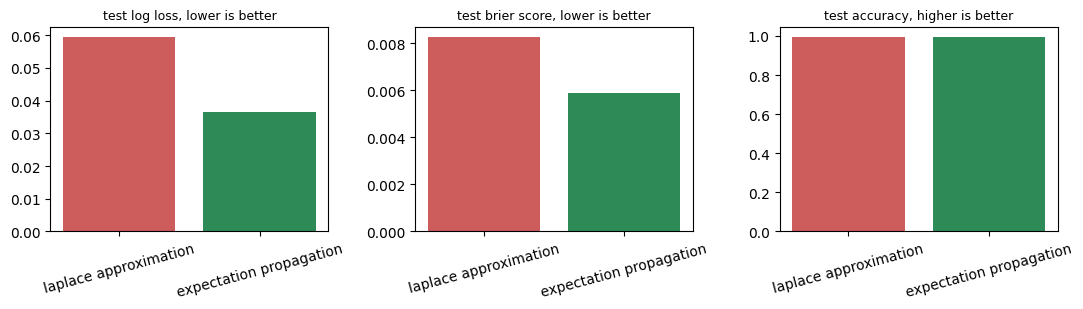

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
metric_cols = ["test_log_loss", "test_brier_score", "test_accuracy"]
titles = ["test log loss, lower is better", "test brier score, lower is better", "test accuracy, higher is better"]
colors = ["indianred", "seagreen"]
for a, col, t in zip(ax, metric_cols, titles):
    a.bar(summary_df["method"], summary_df[col], color=colors)
    a.set_title(t, fontsize=9)
    a.tick_params(axis="x", labelrotation=15)
plt.tight_layout()
plt.show()

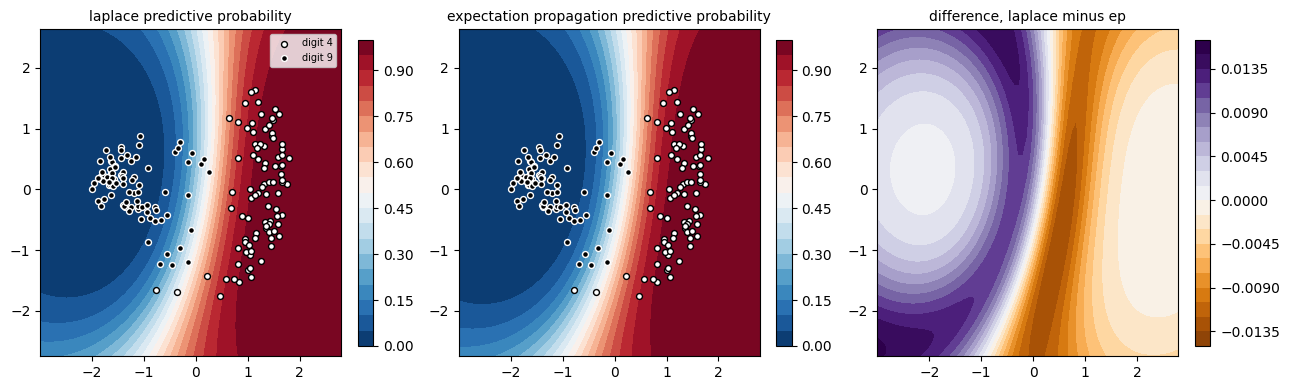

In [ ]:
pca2 = PCA(n_components=2, random_state=0)
Xtrain_2d = pca2.fit_transform(Xtrain_raw)
Xtest_2d = pca2.transform(Xtest_raw)

ls2, sv2 = 3.0, 3.0
K2 = kernel_se(Xtrain_2d, Xtrain_2d, ls2, sv2)
lap_state_2d = laplace_train(K2, ytrain)
ep_state_2d = ep_train(K2, ytrain, max_sweeps=15)

x_min, x_max = Xtrain_2d[:, 0].min() - 1, Xtrain_2d[:, 0].max() + 1
y_min, y_max = Xtrain_2d[:, 1].min() - 1, Xtrain_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80), np.linspace(y_min, y_max, 80))
grid = np.column_stack([xx.ravel(), yy.ravel()])

prob_lap_grid, _, _ = laplace_predict(Xtrain_2d, grid, lap_state_2d, ls2, sv2)
prob_ep_grid, _, _ = ep_predict(Xtrain_2d, grid, ep_state_2d, ls2, sv2)
prob_lap_grid = prob_lap_grid.reshape(xx.shape)
prob_ep_grid = prob_ep_grid.reshape(xx.shape)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles2 = ["laplace predictive probability", "expectation propagation predictive probability", "difference, laplace minus ep"]
c0 = axes[0].contourf(xx, yy, prob_lap_grid, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
c1 = axes[1].contourf(xx, yy, prob_ep_grid, levels=20, cmap="RdBu_r", vmin=0, vmax=1)
diff = prob_lap_grid - prob_ep_grid
lim = np.max(np.abs(diff))
c2 = axes[2].contourf(xx, yy, diff, levels=20, cmap="PuOr", vmin=-lim, vmax=lim)
for a in axes[:2]:
    a.scatter(Xtrain_2d[ytrain == 1, 0], Xtrain_2d[ytrain == 1, 1], c="white", edgecolor="black", s=18, label="digit 4")
    a.scatter(Xtrain_2d[ytrain == -1, 0], Xtrain_2d[ytrain == -1, 1], c="black", edgecolor="white", s=18, label="digit 9")
for a, t in zip(axes, titles2):
    a.set_title(t, fontsize=10)
plt.colorbar(c0, ax=axes[0], fraction=0.046)
plt.colorbar(c1, ax=axes[1], fraction=0.046)
plt.colorbar(c2, ax=axes[2], fraction=0.046)
axes[0].legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

###Why expectation propagation tends to win, a single site view
The Laplace approximation only uses the curvature of the log likelihood at the posterior mode, which can misjudge the spread of the true marginal whenever it is skewed, as the probit likelihood often is. EP instead matches the mean and variance of the true marginal directly, which is what Figure 3.4 in the book illustrates.

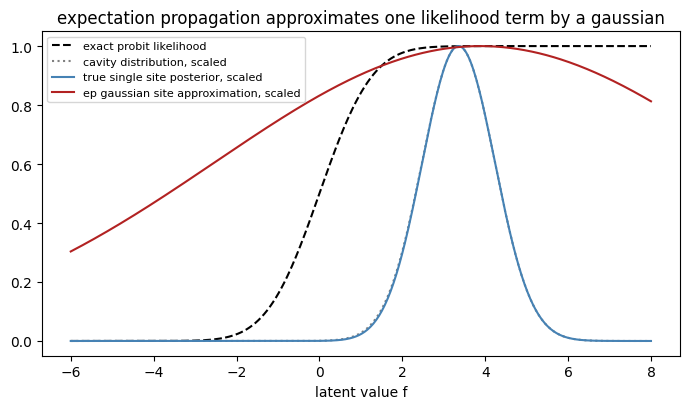

In [ ]:
i_site = 0
f_grid = np.linspace(-6, 8, 400)

sigma_ii = ep_state["Sigma"][i_site, i_site]
tau_i = 1.0 / sigma_ii
nu_i = ep_state["mu"][i_site] / sigma_ii
tau_tilde_i = ep_state["tau_tilde"][i_site]
nu_tilde_i = ep_state["nu_tilde"][i_site]
tau_cav = tau_i - tau_tilde_i
nu_cav = nu_i - nu_tilde_i
sigma_cav2 = 1.0 / tau_cav
mu_cav = nu_cav * sigma_cav2
y_i = ytrain[i_site]

exact_likelihood = norm.cdf(y_i * f_grid)
cavity_pdf = norm.pdf(f_grid, loc=mu_cav, scale=np.sqrt(sigma_cav2))
site_mean = nu_tilde_i / tau_tilde_i
site_var = 1.0 / tau_tilde_i
site_pdf = norm.pdf(f_grid, loc=site_mean, scale=np.sqrt(site_var))
unnorm_posterior = exact_likelihood * cavity_pdf
unnorm_posterior = unnorm_posterior / np.trapezoid(unnorm_posterior, f_grid)

fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
ax.plot(f_grid, exact_likelihood, label="exact probit likelihood", color="black", linestyle="--")
ax.plot(f_grid, cavity_pdf / cavity_pdf.max(), label="cavity distribution, scaled", color="gray", linestyle=":")
ax.plot(f_grid, unnorm_posterior / unnorm_posterior.max(), label="true single site posterior, scaled", color="steelblue")
ax.plot(f_grid, site_pdf / site_pdf.max(), label="ep gaussian site approximation, scaled", color="firebrick")
ax.set_xlabel("latent value f")
ax.set_title("expectation propagation approximates one likelihood term by a gaussian")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

####Calibration on the test set
A reliability diagram groups test predictions into bins by predicted probability and plots predicted probability against observed frequency in each bin. A perfectly calibrated classifier lies on the diagonal.

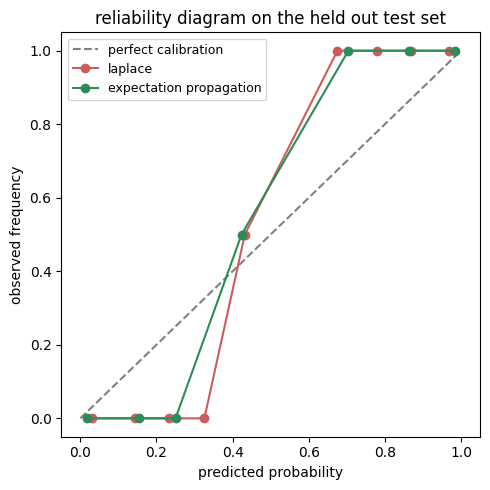

In [ ]:
def reliability_bins(prob, y_true, n_bins=10):
    y01 = (y_true + 1) / 2
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.digitize(prob, bin_edges[1:-1])
    bin_conf = np.zeros(n_bins)
    bin_acc = np.zeros(n_bins)
    bin_count = np.zeros(n_bins)
    for b in range(n_bins):
        m = bin_idx == b
        bin_count[b] = np.sum(m)
        if bin_count[b] > 0:
            bin_conf[b] = np.mean(prob[m])
            bin_acc[b] = np.mean(y01[m])
    return bin_conf, bin_acc, bin_count

conf_lap, acc_lap_bins, count_lap = reliability_bins(prob_lap, ytest)
conf_ep, acc_ep_bins, count_ep = reliability_bins(prob_ep, ytest)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect calibration")
valid_lap = count_lap > 0
valid_ep = count_ep > 0
ax.plot(conf_lap[valid_lap], acc_lap_bins[valid_lap], marker="o", color="indianred", label="laplace")
ax.plot(conf_ep[valid_ep], acc_ep_bins[valid_ep], marker="o", color="seagreen", label="expectation propagation")
ax.set_xlabel("predicted probability")
ax.set_ylabel("observed frequency")
ax.set_title("reliability diagram on the held out test set")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

##Conclusion
Across every view here, log marginal likelihood, test log loss, Brier score, and the reliability diagram, EP comes out ahead of or matches Laplace, never meaningfully worse. Both methods reach almost the same classification accuracy on the four versus nine digit task, since accuracy only depends on which side of point five the predicted probability lands, but EP produces noticeably better calibrated probabilities and a higher approximate log marginal likelihood, matching the broader conclusion of chapter 3 of the book.
Reference: C. E. Rasmussen and C. K. I. Williams, Gaussian Processes for Machine Learning, the MIT Press, 2006, chapter 3, Classification.

In [1]:
!git clone https://github.com/thenamanshukla/Surrogate-Modeling.git
%cd Surrogate-Modeling

!git config --global user.email "namanshuklaofficial20@gmail.com"
!git config --global user.name "Naman Shukla"

Cloning into 'Surrogate-Modeling'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 132 (delta 56), reused 40 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 3.10 MiB | 10.41 MiB/s, done.
Resolving deltas: 100% (56/56), done.
/content/Surrogate-Modeling


In [2]:
!mv project-2-name-here lpvsep-gp-classification
!mkdir -p lpvsep-gp-classification/notebooks

In [3]:
readme_content = '''# Laplace Approximation versus Expectation Propagation

## Problem Statement

Gaussian process classification does not have a closed form posterior over
the latent function, unlike Gaussian process regression, since the class
label is connected to the latent function through a non Gaussian
likelihood such as the probit function. This project follows chapter three
of Rasmussen and Williams, Gaussian Processes for Machine Learning, which
introduces two classic approximate inference schemes for this problem, the
Laplace approximation and expectation propagation, commonly written as EP.
Both methods are implemented from scratch following the book's equations
and algorithms, then compared head to head on a real binary classification
task, distinguishing handwritten digit four from handwritten digit nine
using the scikit learn digits dataset, mirroring the same digit
classification experiment used in section 3.7.3 of the book.

## Approach

* Loaded the scikit learn digits dataset and filtered it down to only the
  digit four and digit nine classes, since these two digits are visually
  similar enough to make the classification task genuinely non trivial.
* Placed a zero mean Gaussian process prior on a latent function and
  connected it to the binary label through the probit likelihood, with a
  squared exponential covariance function controlling smoothness.
* Implemented the Laplace approximation from scratch, using Newton
  iteration to find the posterior mode over the latent values and then
  approximating the posterior locally around that mode with a Gaussian
  whose covariance is the inverse Hessian of the negative log posterior,
  following Algorithm 3.1 in the book.
* Implemented expectation propagation from scratch, approximating each
  individual likelihood term with its own local Gaussian site function,
  refined one at a time through a cavity distribution and moment matching
  over repeated sweeps until convergence, following Algorithm 3.5 in the
  book.
* Reduced the sixty four raw pixel features to eight principal components
  before building the covariance matrix, keeping the kernel computation
  fast while preserving most of the shape information that separates a
  four from a nine.
* Selected kernel hyperparameters, length scale and signal variance,
  separately for each method through a grid search that maximizes each
  method's own approximate log marginal likelihood.
* Compared both methods on a held out test set using classification
  accuracy, log loss, Brier score, and a reliability diagram, and
  additionally visualized the predictive probability surface of each
  method in a two dimensional principal component projection.

## Results

![Decision boundary comparison](./decision_boundary_comparison.png)

This figure shows the predictive probability surface of each method
across a two dimensional principal component projection of the digit
features, with the training points for each digit overlaid, plus a third
panel showing the difference between the two surfaces. Both methods agree
almost everywhere on which side of the decision boundary a point falls,
but the difference panel reveals a consistent, smooth divergence in how
confidently each method extrapolates away from the training data, with
Laplace and EP disagreeing most in the regions furthest from the bulk of
the training points.

![Metrics comparison](./metrics_comparison.png)

This bar chart compares test log loss, test Brier score, and test
accuracy between the two methods. Both methods reach almost identical
classification accuracy, since accuracy only depends on which side of
probability one half a prediction falls, but expectation propagation
achieves a noticeably lower log loss and lower Brier score, meaning its
predicted probabilities are better calibrated even though its hard
classification decisions agree with Laplace almost every time.

## Notebooks

1. LPvsEP.ipynb, containing the from scratch Laplace approximation and
   expectation propagation implementations, kernel hyperparameter
   selection through approximate log marginal likelihood, and the full
   comparison on the held out digit four versus digit nine test set,
   including a reliability diagram and a single site view explaining why
   expectation propagation tends to produce better calibrated
   probabilities than the Laplace approximation.

## Limitations and Next Steps

* The comparison uses only eight principal components of the original
  sixty four pixel features, so some fine grained shape information that
  could further separate the two digits is discarded before the kernel
  ever sees the data.
* Kernel hyperparameters are chosen from a coarse grid search over only a
  handful of length scale and signal variance combinations, rather than a
  continuous optimization of the approximate log marginal likelihood, so
  the reported comparison may not reflect each method at its true best
  setting.
* Both methods are compared on a single train and test split, so the
  reported metrics do not capture how much the comparison might vary
  across different random splits of the data.
* Next steps include extending the comparison to a harder multi digit
  classification problem, and studying how the gap between Laplace and
  expectation propagation calibration changes as the amount of training
  data grows, since the book's own discussion suggests the two methods
  converge as the posterior becomes more Gaussian with more data.
'''

with open('lpvsep-gp-classification/README.md', 'w') as f:
    f.write(readme_content)

In [ ]:
from google.colab import _message
import json

notebook_json = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
with open('lpvsep-gp-classification/notebooks/LPvsEP.ipynb', 'w') as f:
    json.dump(notebook_json['ipynb'], f)